In [ ]:

!pip install kaggle scikit-learn seaborn


import os
os.environ['KAGGLE_USERNAME'] = "senin_kullanici_adin"
os.environ['KAGGLE_KEY'] = "senin_key_numaran"


!kaggle datasets download -d msambare/fer2013
!unzip -q fer2013.zip -d ./dataset
print("Veri seti başarıyla indi ve hazır!")


import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from itertools import cycle


NUM_CLASSES = 7
NUM_EPOCHS = 20
LEARNING_RATE = 0.0001
PATIENCE = 10
MIN_DELTA = 0.0001


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")


train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
  0% 0.00/60.3M [00:00<?, ?B/s]
100% 60.3M/60.3M [00:00<00:00, 1.59GB/s]
Veri seti başarıyla indi ve hazır!
Kullanılan Cihaz: cuda


In [ ]:

def create_resnet18_fine_tune_model(num_classes):

    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)


    for param in model.parameters():
        param.requires_grad = False


    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)


    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.layer3.parameters():
        param.requires_grad = True


    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    return model


model = create_resnet18_fine_tune_model(NUM_CLASSES)
model = model.to(device)

print("Model başarıyla Fine-Tuning için güncellendi.")


data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]),
    'test': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
    ]),
}

data_dir = './dataset'
image_datasets = {
    'train': datasets.ImageFolder(root=data_dir + '/train', transform=data_transforms['train']),
    'test': datasets.ImageFolder(root=data_dir + '/test', transform=data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=64, shuffle=True, num_workers=2),
    'test': DataLoader(image_datasets['test'], batch_size=64, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes

print(f"Eğitim Seti Boyutu: {dataset_sizes['train']} resim")
print(f"Test Seti Boyutu: {dataset_sizes['test']} resim")


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 77.4MB/s]


Model başarıyla Fine-Tuning için güncellendi.
Eğitim Seti Boyutu: 28709 resim
Test Seti Boyutu: 7178 resim


In [ ]:

def train_model(model, criterion, optimizer, num_epochs=20):
    global best_val_acc
    since = time.time()
    epochs_no_improve = 0
    last_val_loss = float('inf')

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')


            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.item())
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.item())


            if phase == 'test':

                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc.item()
                    torch.save(model.state_dict(), 'best_resnet18_emotion_model.pth')
                    epochs_no_improve = 0
                    print(f'Yeni en iyi doğruluk ({best_val_acc:.4f}) ile Model kaydedildi.')


                if last_val_loss - epoch_loss < MIN_DELTA:
                    epochs_no_improve += 1
                else:
                    epochs_no_improve = 0

                last_val_loss = epoch_loss


        if epochs_no_improve >= PATIENCE:
            print(f'\nErken Durdurma etkinleştirildi. {PATIENCE} epoch boyunca iyileşme olmadı.')
            break

    time_elapsed = time.time() - since
    print(f'\nEğitim tamamlandı! Süre: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'En iyi doğruluk (Best val Acc): {best_val_acc:.4f}')


    model.load_state_dict(torch.load('best_resnet18_emotion_model.pth'))
    return model


trained_model = train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS)


Epoch 1/20
----------
train Loss: 1.7434 Acc: 0.3121
test Loss: 1.6162 Acc: 0.3697
Yeni en iyi doğruluk (0.3697) ile Model kaydedildi.

Epoch 2/20
----------
train Loss: 1.5573 Acc: 0.3941
test Loss: 1.4964 Acc: 0.4182
Yeni en iyi doğruluk (0.4182) ile Model kaydedildi.

Epoch 3/20
----------
train Loss: 1.4694 Acc: 0.4351
test Loss: 1.4370 Acc: 0.4391
Yeni en iyi doğruluk (0.4391) ile Model kaydedildi.

Epoch 4/20
----------
train Loss: 1.4051 Acc: 0.4571
test Loss: 1.4166 Acc: 0.4583
Yeni en iyi doğruluk (0.4583) ile Model kaydedildi.

Epoch 5/20
----------
train Loss: 1.3465 Acc: 0.4840
test Loss: 1.3684 Acc: 0.4742
Yeni en iyi doğruluk (0.4742) ile Model kaydedildi.

Epoch 6/20
----------
train Loss: 1.3014 Acc: 0.5063
test Loss: 1.3421 Acc: 0.4844
Yeni en iyi doğruluk (0.4844) ile Model kaydedildi.

Epoch 7/20
----------
train Loss: 1.2435 Acc: 0.5275
test Loss: 1.3372 Acc: 0.4862
Yeni en iyi doğruluk (0.4862) ile Model kaydedildi.

Epoch 8/20
----------
train Loss: 1.1979 Acc: 0

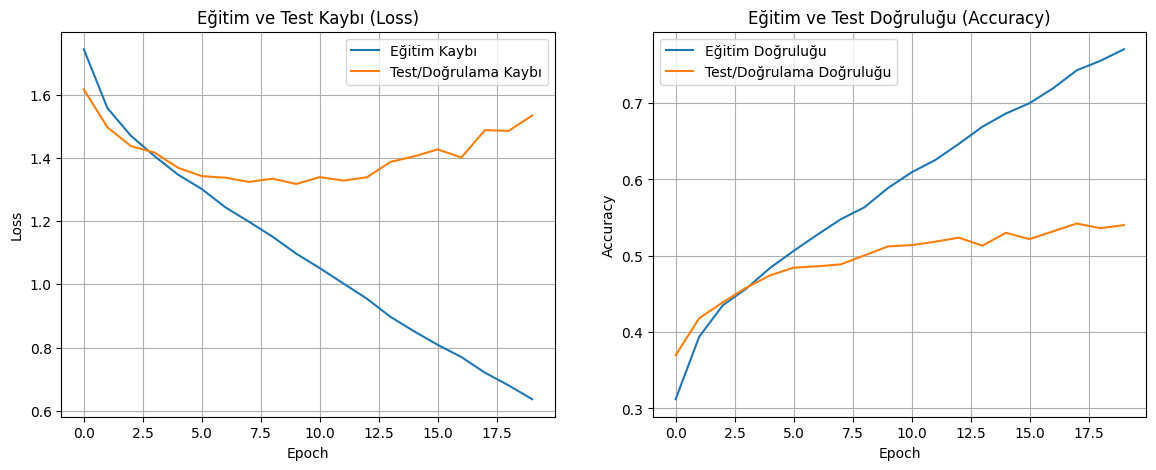


--- Confusion Matrix ---


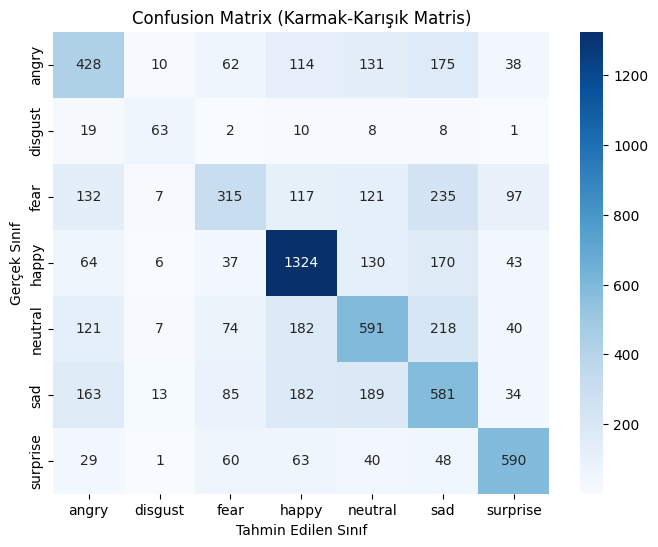

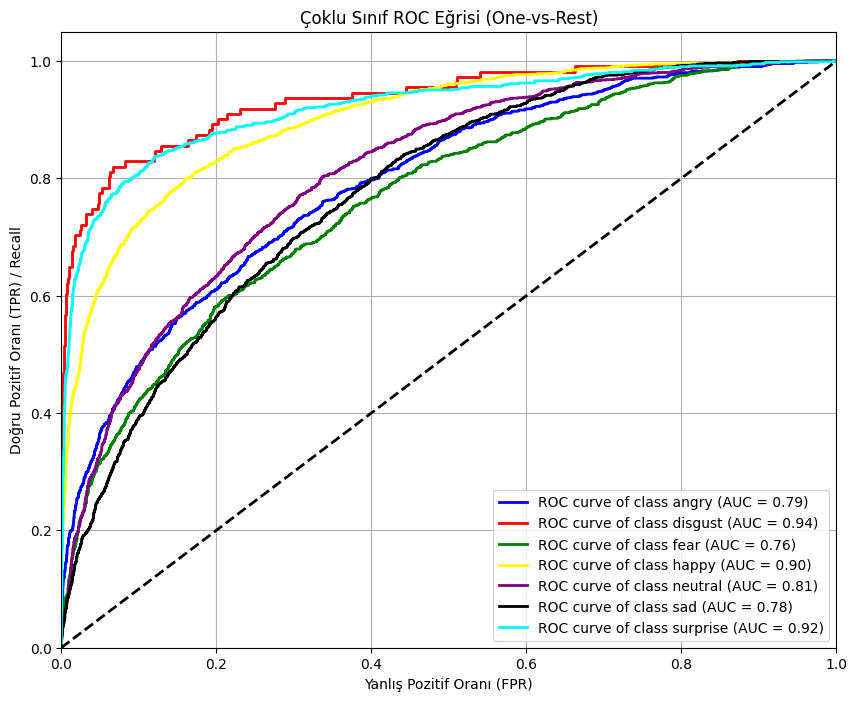


--- Her Sınıf İçin AUC Değerleri ---
Angry: 0.7940
Disgust: 0.9357
Fear: 0.7646
Happy: 0.9012
Neutral: 0.8099
Sad: 0.7781
Surprise: 0.9213


In [ ]:

plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Eğitim Kaybı')
plt.plot(val_losses, label='Test/Doğrulama Kaybı')
plt.title('Eğitim ve Test Kaybı (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Eğitim Doğruluğu')
plt.plot(val_accs, label='Test/Doğrulama Doğruluğu')
plt.title('Eğitim ve Test Doğruluğu (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


def visualize_confusion_matrix(model, dataloader, class_names, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Karmak-Karışık Matris)')
    plt.xlabel('Tahmin Edilen Sınıf')
    plt.ylabel('Gerçek Sınıf')
    plt.show()

print("\n--- Confusion Matrix ---")
visualize_confusion_matrix(trained_model, dataloaders['test'], class_names, device)



def get_predictions_and_scores(model, dataloader, device):
    model.eval()
    all_labels = []
    all_scores = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            scores = torch.nn.functional.softmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(scores.cpu().numpy())

    return np.array(all_labels), np.array(all_scores)

y_true, y_score = get_predictions_and_scores(trained_model, dataloaders['test'], device)
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'yellow', 'purple', 'black', 'cyan'])

for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR) / Recall')
plt.title('Çoklu Sınıf ROC Eğrisi (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("\n--- Her Sınıf İçin AUC Değerleri ---")
for name, auc_val in zip(class_names, roc_auc.values()):
    print(f"{name.capitalize()}: {auc_val:.4f}")